# Exploratory Data Analysis

This notebook explores the support ticket datasets used in the Support Ops Copilot project.

### Objectives
- Understand dataset structure and quality
- Analyze classification targets
- Explore ticket text
- Check multilingual data
- Investigate the feasibility of resolution-time prediction

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


# Define file paths
file1 = '../datasets/raw/aa_dataset-tickets-multi-lang-5-2-50-version.csv'
file2 = '../datasets/raw/customer_support_tickets.csv'


In [7]:
file1 = "../datasets/raw/aa_dataset-tickets-multi-lang-5-2-50-version.csv"
file2 = "../datasets/raw/customer_support_tickets.csv"

df1 = pd.read_csv(file1, low_memory=False)
df2 = pd.read_csv(file2, low_memory=False)

print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)

Dataset 1: (28587, 16)
Dataset 2: (8469, 17)


## Dataset Summary

In [8]:
summary = pd.DataFrame({
    "Dataset": ["Dataset 1", "Dataset 2"],
    "Rows": [len(df1), len(df2)],
    "Columns": [df1.shape[1], df2.shape[1]],
    "Duplicate Rows": [df1.duplicated().sum(), df2.duplicated().sum()],
    "Missing Values": [df1.isnull().sum().sum(), df2.isnull().sum().sum()]
})

summary

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,Dataset 1,28587,16,0,98376
1,Dataset 2,8469,17,0,19919


## Dataset 1 - Overview

In [22]:
df1.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,subject_length,body_length,answer_length
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,31.0,751,643.0
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,18.0,544,501.0
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,50.0,534,504.0
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,33.0,605,542.0
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,54.0,677,273.0


In [9]:
missing_df1 = pd.DataFrame({
    "Column": df1.columns,
    "Missing Values": df1.isnull().sum().values,
    "Missing %": (df1.isnull().mean().values * 100).round(2)
})

missing_df1[missing_df1["Missing Values"] > 0].sort_values(
    "Missing %",
    ascending=False
)

,Column,Missing Values,Missing %
15,tag_8,28022,98.02
14,tag_7,26547,92.86
13,tag_6,22713,79.45
12,tag_5,14042,49.12
0,subject,3838,13.43
11,tag_4,3058,10.70
10,tag_3,136,0.48
9,tag_2,13,0.05
2,answer,7,0.02


## Classification Target Analysis

In [10]:
target_summary = pd.DataFrame({
    "Type": df1["type"].value_counts(),
    "Type %": (df1["type"].value_counts(normalize=True) * 100).round(2),
    "Priority": df1["priority"].value_counts(),
    "Priority %": (df1["priority"].value_counts(normalize=True) * 100).round(2)
})

target_summary

,Type,Type %,Priority,Priority %
Change,2922.0,10.22,NaN,NaN
Incident,11466.0,40.11,NaN,NaN
Problem,6012.0,21.03,NaN,NaN
Request,8187.0,28.64,NaN,NaN
high,NaN,NaN,11178.0,39.10
low,NaN,NaN,5894.0,20.62
medium,NaN,NaN,11515.0,40.28


In [11]:
print("Type Distribution")
display(df1["type"].value_counts().to_frame("Count"))

print("Priority Distribution")
display(df1["priority"].value_counts().to_frame("Count"))

Type Distribution


,Count
type,
Incident,11466
Request,8187
Problem,6012
Change,2922


Priority Distribution


,Count
priority,
medium,11515
high,11178
low,5894


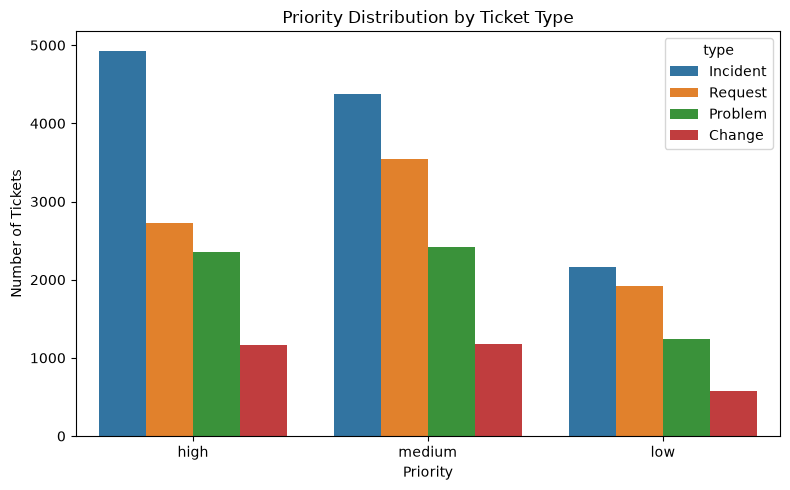

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df1, x="priority", hue="type")

plt.title("Priority Distribution by Ticket Type")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.tight_layout()

plt.savefig("../notebooks/images/d1_priority_type.png")
plt.show()

## Language Distribution

In [17]:
language_summary = pd.DataFrame({
    "Count": df1["language"].value_counts(),
    "Percentage": (df1["language"].value_counts(normalize=True) * 100).round(2)
})

language_summary

,Count,Percentage
language,,
en,16338,57.15
de,12249,42.85


## Ticket Text Analysis

In [18]:
df1["subject_length"] = df1["subject"].str.len()
df1["body_length"] = df1["body"].str.len()
df1["answer_length"] = df1["answer"].str.len()

text_summary = pd.DataFrame({
    "Text Field": ["Subject", "Body", "Answer"],
    "Mean Length": [
        df1["subject_length"].mean(),
        df1["body_length"].mean(),
        df1["answer_length"].mean()
    ],
    "Median Length": [
        df1["subject_length"].median(),
        df1["body_length"].median(),
        df1["answer_length"].median()
    ],
    "Missing Values": [
        df1["subject"].isnull().sum(),
        df1["body"].isnull().sum(),
        df1["answer"].isnull().sum()
    ]
}).round(2)

text_summary

,Text Field,Mean Length,Median Length,Missing Values
0,Subject,44.52,42.0,3838
1,Body,387.26,386.0,0
2,Answer,387.27,390.0,7


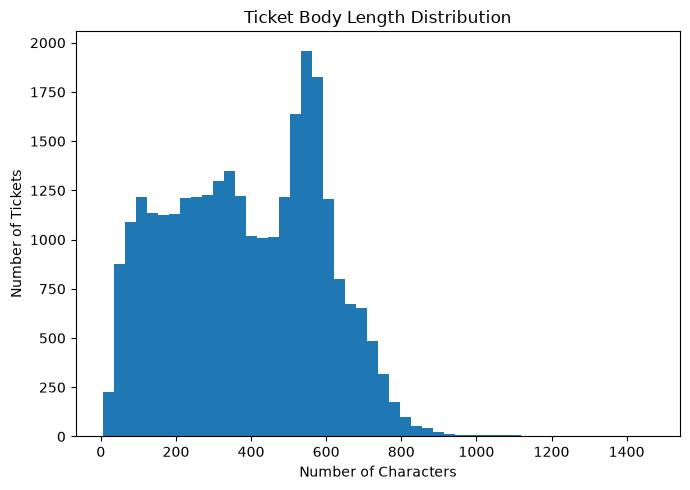

In [21]:
plt.figure(figsize=(7, 5))

plt.hist(df1["body_length"].dropna(), bins=50)

plt.title("Ticket Body Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tickets")
plt.tight_layout()

plt.savefig("../notebooks/images/d1_body_length.png")
plt.show()

## Dataset 2 Overview

In [23]:
df2.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [24]:
missing_df2 = pd.DataFrame({
    "Column": df2.columns,
    "Missing Values": df2.isnull().sum().values,
    "Missing %": (df2.isnull().mean().values * 100).round(2)
})

missing_df2[missing_df2["Missing Values"] > 0].sort_values(
    "Missing %",
    ascending=False
)

,Column,Missing Values,Missing %
11,Resolution,5700,67.30
15,Time to Resolution,5700,67.30
16,Customer Satisfaction Rating,5700,67.30
14,First Response Time,2819,33.29


## Dataset 2 Resolution-Time Investigation

In [25]:
print("Dataset 2 columns:")
print(df2.columns.tolist())

Dataset 2 columns:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [26]:
resolution_columns = [
    column for column in df2.columns
    if "resolution" in column.lower() or "response" in column.lower()
]

df2[resolution_columns].head()

,Resolution,First Response Time,Time to Resolution
0,NaN,2023-06-01 12:15:36,NaN
1,NaN,2023-06-01 16:45:38,NaN
2,Case maybe show recently my computer follow.,2023-06-01 11:14:38,2023-06-01 18:05:38
3,Try capital clearly never color toward story.,2023-06-01 07:29:40,2023-06-01 01:57:40
4,West decision evidence bit.,2023-06-01 00:12:42,2023-06-01 19:53:42


### Resolution-Time Decision

Dataset 2 contains resolution-related fields, but it does not contain a valid ticket creation timestamp.

Therefore, a true resolution-time duration cannot be reliably calculated from the available timestamps.

Using `First Response Time` as a substitute would not represent actual resolution duration and could introduce leakage.

**Decision:** Resolution-time prediction is dropped from the final Support Ops Copilot system.

Dataset 2 is retained for analysis and documentation but is not used to train a resolution-time prediction model.

## Key EDA Findings

- Dataset 1 contains 28,587 tickets and 16 columns.
- Dataset 1 provides suitable targets for ticket type and priority classification.
- Dataset 1 contains English and German tickets.
- Historical `answer` text provides a suitable source for the RAG knowledge base.
- Dataset 1 contains missing values, particularly in some optional fields.
- Dataset 2 contains 8,469 tickets and 17 columns.
- Dataset 2 does not contain a valid ticket creation timestamp.
- Resolution-time prediction is therefore excluded from the final system.
- `answer` is retained for RAG but excluded from classification features.